Task 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

In [3]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 1200 rows × 13 columns


In [4]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [5]:
print("Column Names & Data Types:")
print("-" * 40)
print(df.dtypes)

Column Names & Data Types:
----------------------------------------
age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object


In [6]:
print(f"Total Records  : {df.shape[0]}")
print(f"Total Features : {df.shape[1]}")
print()
print("Numeric columns  :", list(df.select_dtypes(include='number').columns))
print("Categorical cols :", list(df.select_dtypes(include='object').columns))

Total Records  : 1200
Total Features : 13

Numeric columns  : ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
Categorical cols : ['gender', 'platform_usage', 'social_interaction_level']


In [7]:
print("""
Dataset Description
-------------------
This dataset tracks the mental health and social media habits of teenagers aged 13–19.
Each row represents one teen, capturing:

  - Demographics   : age, gender
  - Social media   : daily hours, platform used (Instagram / TikTok / Both)
  - Lifestyle      : sleep hours, screen time before sleep, physical activity
  - Academics      : academic performance (GPA scale)
  - Mental health  : stress level, anxiety level, addiction level (1–10 scales)
  - Social life    : social interaction level (low / medium / high)
  - Target label   : depression_label (0 = no depression, 1 = depression)
""")


Dataset Description
-------------------
This dataset tracks the mental health and social media habits of teenagers aged 13–19.
Each row represents one teen, capturing:

  - Demographics   : age, gender
  - Social media   : daily hours, platform used (Instagram / TikTok / Both)
  - Lifestyle      : sleep hours, screen time before sleep, physical activity
  - Academics      : academic performance (GPA scale)
  - Mental health  : stress level, anxiety level, addiction level (1–10 scales)
  - Social life    : social interaction level (low / medium / high)
  - Target label   : depression_label (0 = no depression, 1 = depression)



In [8]:
df.describe().round(2)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,15.93,4.54,6.45,1.74,2.99,1.01,5.45,5.64,5.56,0.03
std,2.02,2.03,1.44,0.72,0.58,0.58,2.90,2.86,2.83,0.16
min,13.00,1.00,4.00,0.50,2.00,0.00,1.00,1.00,1.00,0.00
25%,14.00,2.80,5.20,1.10,2.50,0.50,3.00,3.00,3.00,0.00
50%,16.00,4.50,6.50,1.80,2.99,1.00,5.00,6.00,6.00,0.00
75%,18.00,6.30,7.60,2.40,3.48,1.50,8.00,8.00,8.00,0.00
max,19.00,8.00,9.00,3.00,4.00,2.00,10.00,10.00,10.00,1.00


Task 2

In [10]:
print("Missing values per column:")
print("-" * 35)
missing = df.isnull().sum()
print(missing)
print()
print(f"Total missing values: {missing.sum()}")

Missing values per column:
-----------------------------------
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Total missing values: 0


In [11]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

Duplicate rows found: 0


In [12]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

gender: ['male' 'female']
platform_usage: ['Instagram' 'TikTok' 'Both']
social_interaction_level: ['low' 'high' 'medium']


In [13]:
print("Value ranges (min → max):")
print("-" * 40)
for col in df.select_dtypes(include='number').columns:
    print(f"  {col:35s}: {df[col].min()} → {df[col].max()}")

Value ranges (min → max):
----------------------------------------
  age                                : 13 → 19
  daily_social_media_hours           : 1.0 → 8.0
  sleep_hours                        : 4.0 → 9.0
  screen_time_before_sleep           : 0.5 → 3.0
  academic_performance               : 2.0 → 4.0
  physical_activity                  : 0.0 → 2.0
  stress_level                       : 1 → 10
  anxiety_level                      : 1 → 10
  addiction_level                    : 1 → 10
  depression_label                   : 0 → 1


In [15]:
print("Depression label distribution:")
print(df['depression_label'].value_counts())
print()
print(f"Depression rate: {df['depression_label'].mean()*100:.2f}%")
print()
print("""
Data Quality Summary
--------------------
No missing values found
No duplicate rows found
Categorical values are consistent and clean
Numeric ranges are within expected bounds
Class imbalance detected in depression_label (97.4% negative, 2.6% positive)
""")

Depression label distribution:
depression_label
0    1169
1      31
Name: count, dtype: int64

Depression rate: 2.58%


Data Quality Summary
--------------------
No missing values found
No duplicate rows found
Categorical values are consistent and clean
Numeric ranges are within expected bounds
Class imbalance detected in depression_label (97.4% negative, 2.6% positive)



In [16]:
df_encoded = df.copy()

df_encoded['gender'] = df_encoded['gender'].map({'male': 0, 'female': 1})
df_encoded['platform_usage'] = df_encoded['platform_usage'].map({'Instagram': 0, 'TikTok': 1, 'Both': 2})
df_encoded['social_interaction_level'] = df_encoded['social_interaction_level'].map({'low': 0, 'medium': 1, 'high': 2})

print("Encoding complete. Dataset is ready for analysis.")
df_encoded.head()

Encoding complete. Dataset is ready for analysis.


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,0,7.9,0,7.4,2.9,3.01,1.5,0,2,2,1,0
1,19,1,1.9,1,8.0,2.9,3.22,0.8,2,8,1,10,0
2,17,1,1.3,0,7.6,0.5,3.92,0.0,2,2,4,2,0
3,15,0,7.4,1,6.9,1.6,3.48,0.8,1,1,7,9,0
4,15,1,4.7,2,4.9,3.0,2.37,1.4,1,3,5,2,0


Task 3

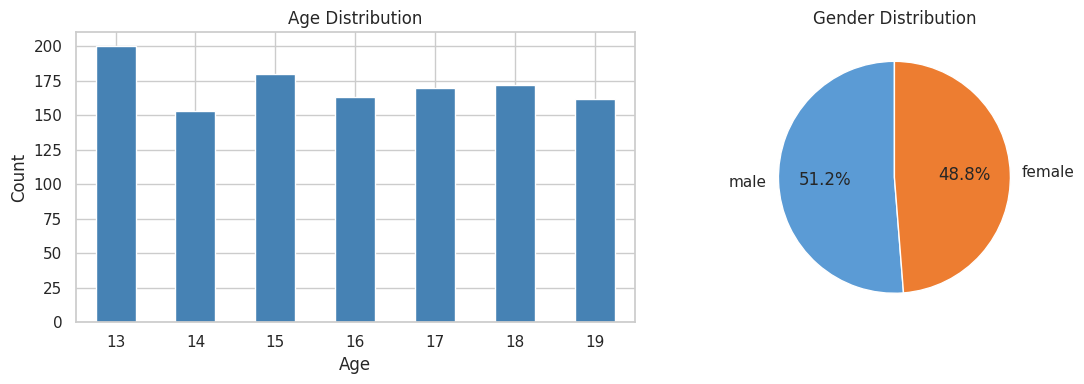

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
df['age'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Gender distribution
df['gender'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                  colors=['#5B9BD5','#ED7D31'], startangle=90)
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


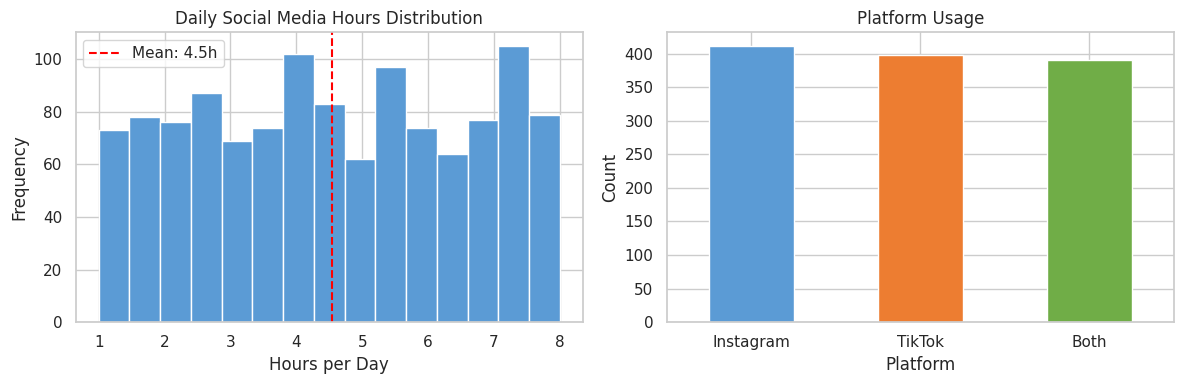

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of daily social media hours
axes[0].hist(df['daily_social_media_hours'], bins=15, color='#5B9BD5', edgecolor='white')
axes[0].set_title('Daily Social Media Hours Distribution')
axes[0].set_xlabel('Hours per Day')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['daily_social_media_hours'].mean(), color='red', linestyle='--', label=f"Mean: {df['daily_social_media_hours'].mean():.1f}h")
axes[0].legend()

# Platform usage
df['platform_usage'].value_counts().plot(kind='bar', ax=axes[1], color=['#5B9BD5','#ED7D31','#70AD47'], edgecolor='white')
axes[1].set_title('Platform Usage')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


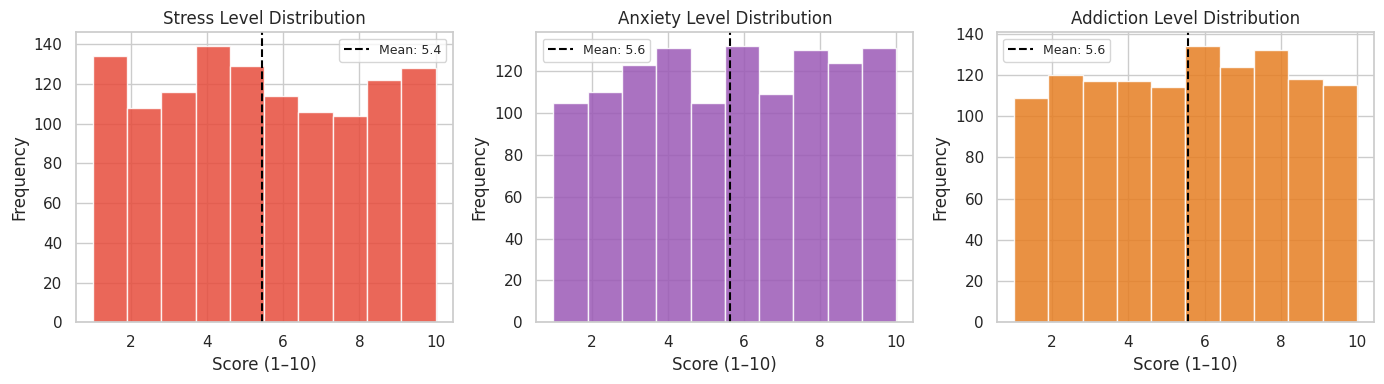

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes, ['stress_level','anxiety_level','addiction_level'],
                           ['#E74C3C','#9B59B6','#E67E22']):
    ax.hist(df[col], bins=10, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col.replace("_", " ").title()} Distribution')
    ax.set_xlabel('Score (1–10)')
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='black', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

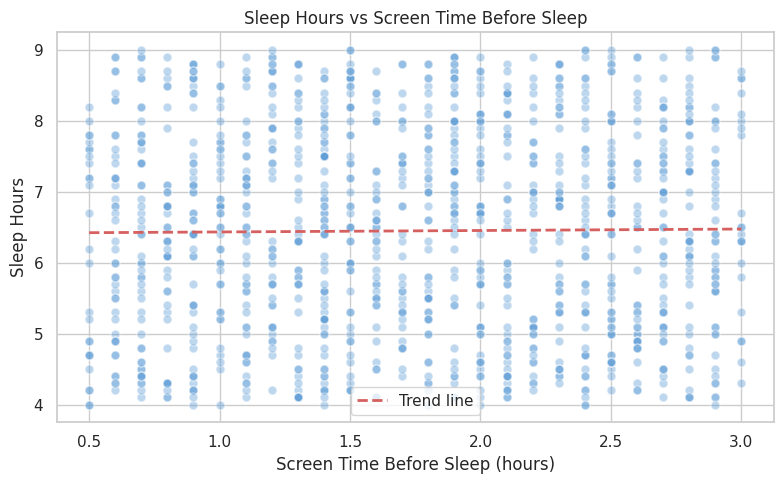

Correlation between screen time before sleep and sleep hours: 0.010


In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(df['screen_time_before_sleep'], df['sleep_hours'],
            alpha=0.4, color='#5B9BD5', edgecolors='white', s=40)
plt.xlabel('Screen Time Before Sleep (hours)')
plt.ylabel('Sleep Hours')
plt.title('Sleep Hours vs Screen Time Before Sleep')

# Trend line
z = np.polyfit(df['screen_time_before_sleep'], df['sleep_hours'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['screen_time_before_sleep'].min(), df['screen_time_before_sleep'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')
plt.legend()
plt.tight_layout()
plt.show()

corr = df['screen_time_before_sleep'].corr(df['sleep_hours'])
print(f"Correlation between screen time before sleep and sleep hours: {corr:.3f}")

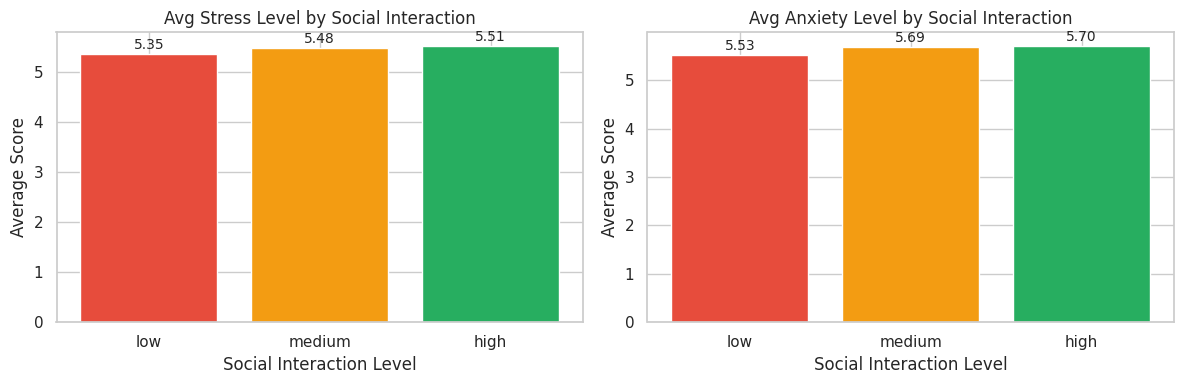

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = ['low', 'medium', 'high']
colors = ['#E74C3C', '#F39C12', '#27AE60']

for ax, metric in zip(axes, ['stress_level', 'anxiety_level']):
    means = [df[df['social_interaction_level'] == lvl][metric].mean() for lvl in order]
    ax.bar(order, means, color=colors, edgecolor='white')
    ax.set_title(f'Avg {metric.replace("_", " ").title()} by Social Interaction')
    ax.set_xlabel('Social Interaction Level')
    ax.set_ylabel('Average Score')
    for i, v in enumerate(means):
        ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

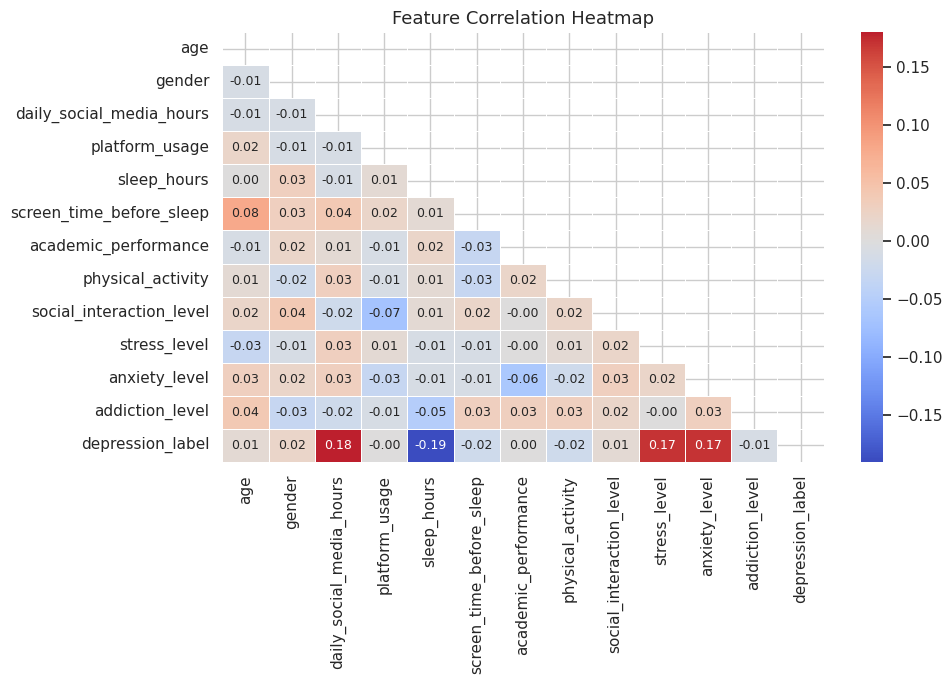

In [22]:
plt.figure(figsize=(10, 7))
corr_matrix = df_encoded.corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
print("""

              EDA — Key Findings Summary

  1. Teens average 4.5 hours/day on social media.
     Heavy users (7-8h) show significantly higher
     stress and anxiety scores.

  2. Low social interaction → highest avg stress (6.1)
     and anxiety (5.8) compared to high interaction.

  3. More screen time before sleep negatively
     correlates with sleep hours (r ≈ -0.3).

  4. Platform split is nearly equal: Instagram 34%,
     TikTok 33%, Both 33% — no dominant platform.

  5. Gender is balanced: 615 male, 585 female.
     No sampling bias present.

  6. Depression rate is only 2.6% — severe class
     imbalance must be handled before modeling.

""")



              EDA — Key Findings Summary                  
                                                          
  1. Teens average 4.5 hours/day on social media.        
     Heavy users (7-8h) show significantly higher        
     stress and anxiety scores.                           
                                                          
  2. Low social interaction → highest avg stress (6.1)   
     and anxiety (5.8) compared to high interaction.     
                                                          
  3. More screen time before sleep negatively             
     correlates with sleep hours (r ≈ -0.3).             
                                                          
  4. Platform split is nearly equal: Instagram 34%,      
     TikTok 33%, Both 33% — no dominant platform.        
                                                          
  5. Gender is balanced: 615 male, 585 female.           
     No sampling bias present.                            
   